# Symmetries in closed and open quantum systems

### Symmetries in Hamiltonian Systems

In quantum systems, a **symmetry** corresponds to a transformation under which the system remains invariant. If the Hamiltonian $ \hat{H} $ commutes with a symmetry operator $ \hat{S} $:

$$
[\hat{H}, \hat{S}] = 0
$$

then the observable associated with $ \hat{S} $ is conserved over time. According to **Noether's theorem**, symmetries lead to conservation laws. For example, $U(1)$ symmetry often corresponds to the conservation of particle number or charge.


### Example: Jaynes-Cummings Model

The **Jaynes-Cummings model** describes the interaction between a two-level atom and a single quantized electromagnetic field mode. Its Hamiltonian is:

$$
\hat{H}_{JC} = \hbar \omega \hat{a}^\dagger \hat{a} + \frac{\hbar \omega_0}{2} \hat{\sigma}_z + \hbar g (\hat{a}^\dagger \hat{\sigma}_- + \hat{a} \hat{\sigma}_+)
$$

Here, $ \hat{a}^\dagger $ and $ \hat{a} $ are the creation/annihilation operators for the field, and $ \hat{\sigma}_z, \hat{\sigma}_\pm $ are Pauli operators for the atom.

This model has $U(1)$ symmetry, meaning the total number of excitations:

$$
\hat{N} = \hat{a}^\dagger \hat{a} + \hat{\sigma}_+ \hat{\sigma}_-
$$

is conserved, as:

$$
[\hat{H}_{JC}, \hat{N}] = 0
$$

Thus, the total number of particles (photons + atomic excitations) is constant.

In [1]:
using Pkg
Pkg.activate("/home/camillaberti/tp4-exercises/julia")
Pkg.status()

  Activating project at `~/tp4-exercises/julia`


Status `~/tp4-exercises/julia/Project.toml`
  [6e4b80f9] BenchmarkTools v1.6.3
  [13f3f980] CairoMakie v0.15.9
  [7073ff75] IJulia v1.34.4
  [1dea7af3] OrdinaryDiffEq v6.108.0
  [6c2fb7c5] QuantumToolbox v0.44.0
  [789caeaf] StochasticDiffEq v6.100.0


In [2]:
using QuantumToolbox
using CairoMakie

In [2]:
const N = 10 # cutoff for the Fock space of the cavity

const a = tensor(destroy(N), qeye(2)) # cavity annihilation operator

const σm = tensor(qeye(N), sigmam()) # atomic lowering operator
const σp = tensor(qeye(N), sigmap()) # atomic raising operator
const σz = tensor(qeye(N), sigmaz()) # atomic z operator

function H(ωc, ωq, g)
    return ωc * a' * a + ωq * σz / 2 + g * (a' * σm + a * σp)
end

H (generic function with 1 method)

Let's define the operator $\hat{\Pi} = \exp \left( i \pi \hat{N} \right) $, and let's calculate the commutator $[\hat{H}_{JC}, \hat{\Pi}]$ to verify that the Hamiltonian commutes with the parity operator.

In [3]:
ωc = 1
ωq = 1
g = 0.01

Π = exp(1im * π * (a' * a + σp * σm)) #second term is the atomic excitation operator, 1 when atom is in |e>, 0 if |g>
H_JC = H(ωc, ωq, g)



Quantum Object:   type=Operator()   dims=([10, 2], [10, 2])   size=(20, 20)   ishermitian=true
20×20 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 38 stored entries:
⎡⡑⢌⠠⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠂⡑⢌⠠⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠂⡑⢌⠠⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠂⡑⢌⠠⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠂⡑⢌⎦

In [4]:
norm(commutator(H_JC, Π)) 

2.326457698764093e-15

Was is just a coincidence? Let's try calculate it for different values of $\theta$.

In [5]:
function Π_θ(θ)
    return exp(1im * θ * (a' * a + σp * σm))
end

θ_list = range(0, 2π, 101) # 101 elements from 0 to 2π, in order to include also π
norm_list = map(θ -> norm(commutator(H_JC, Π_θ(θ))), θ_list)

all(isapprox.(norm_list, 0, atol=1e-10)) #check if all commutators are zero with a tolerance of 1e-10

true

Let's try with the Quantum Rabi Model now

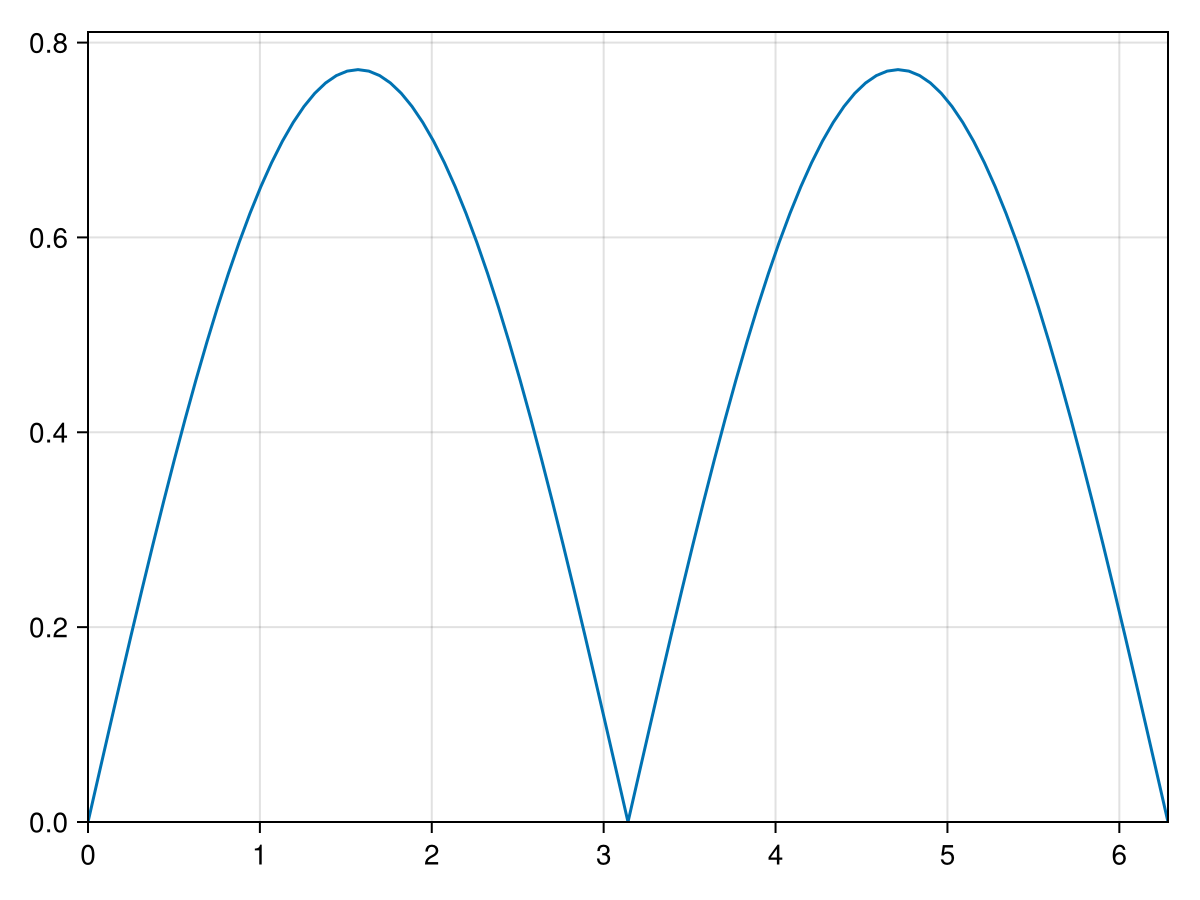

In [6]:
H_QRM = ωc * a' * a + ωq * σz / 2 + g * (a + a') * (σm + σp)

norm_list = map(θ -> norm(commutator(H_QRM, Π_θ(θ))), θ_list)

fig = Figure()
ax = Axis(fig[1, 1])

lines!(ax, θ_list, norm_list)
xlims!(ax, 0, 2π)
ylims!(ax, 0, nothing)

fig

As can be seen, the parity is conserved only for discrete values of $\theta$: $\theta = 0, \pi$.

## Exercise

We now know that there is a symmetry in our system, and that we can block-diagonalize the Hamiltonian. In the JC model, each block corresponds to a different number of excitations. In the Rabi model, the blocks correspond to different values of the parity: even and odd.

Find a way to block-diagonalize the Hamiltonian.

> **Hint:** Choose a starting vector (e.g., $|\Psi_0 \rangle = |0, e\rangle$) and check all the connected vectors through the Hamiltonian such that $\langle \Psi_i | \hat{H} | \Psi_0 \rangle \neq 0$. These vectors will form a block. Repeat the process for the remaining vectors.

In [7]:
function block_diagonalize(H)
    #M = get_data(H)           
    n = size(H, 1)            
    visited = falses(n)       #vector of n boolean variables set to false
    permutation = Int[]       # permutation of the basis startes

    for i in 1:n
        if !visited[i]
            block = Int[]
            queue = [i] #vector with element i
            visited[i] = true
            
            while !isempty(queue)
                u = popfirst!(queue) #first element of queue is removed and assigned to u
                push!(block, u) #pushbak of u in vector block
                
                
                tol = 1e-10
                connections = findall(x -> abs(x) > tol, H[:, u]) #findall returns the indices of the non-zero elements in the u-th column of H
                #connections = findall(!iszero, H[:, u])
                
                for v in connections
                    if !visited[v]
                        visited[v] = true
                        push!(queue, v)
                    end
                end
            end
            # pushback of the block in the permutation vector
            append!(permutation, block)
        end
    end
    
    # return H permuted and permutation vector
    return H[permutation, permutation], permutation
end

block_diagonalize (generic function with 1 method)

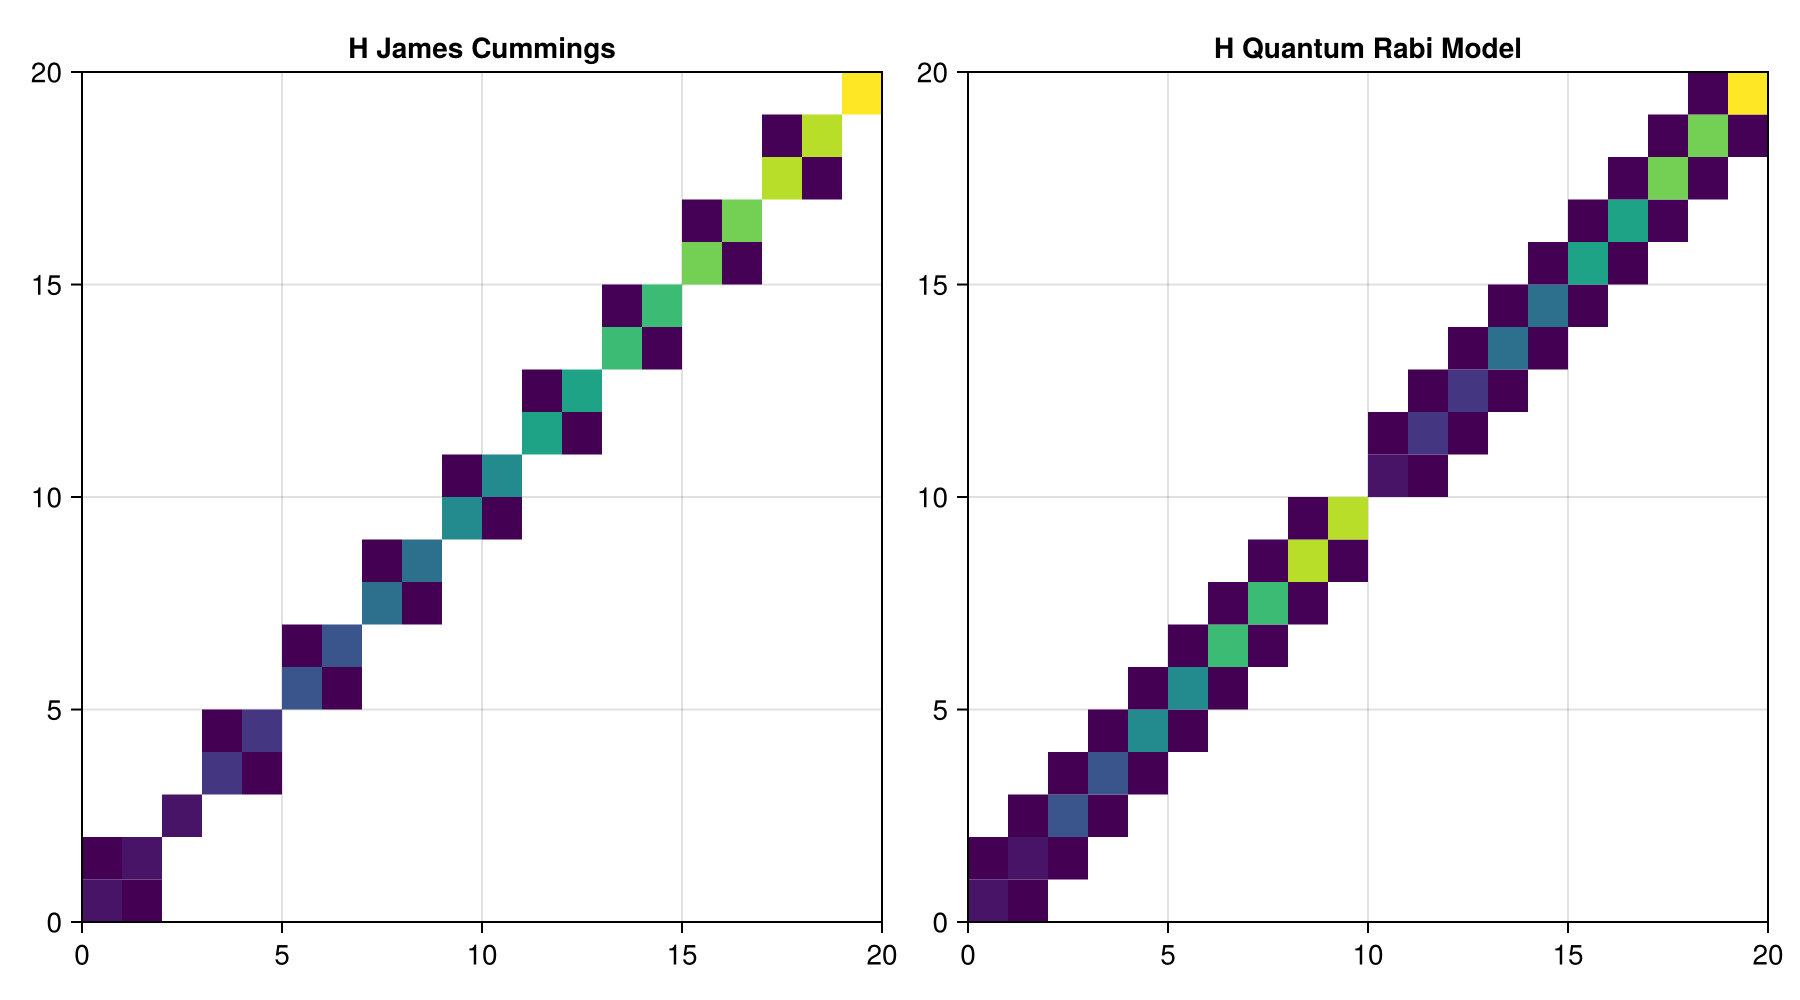

[1, 4, 2, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15, 18, 17, 20, 19][1, 4, 5, 8, 9, 12, 13, 16, 17, 20, 2, 3, 6, 7, 10, 11, 14, 15, 18, 19]

In [8]:
H_JC_block, p_JC = block_diagonalize(H_JC)
H_QRM_block, p_QRM = block_diagonalize(H_QRM)

fig = Figure(size = (900,500))
ax1 = Axis(fig[1,1], title="H James Cummings")
ax2 = Axis(fig[1,2], title="H Quantum Rabi Model")
spy!(ax1, abs.(H_JC_block))
spy!(ax2, abs.(H_QRM_block))
display(fig)
print(p_JC)
print(p_QRM)